mean acceptance probability: 0.065


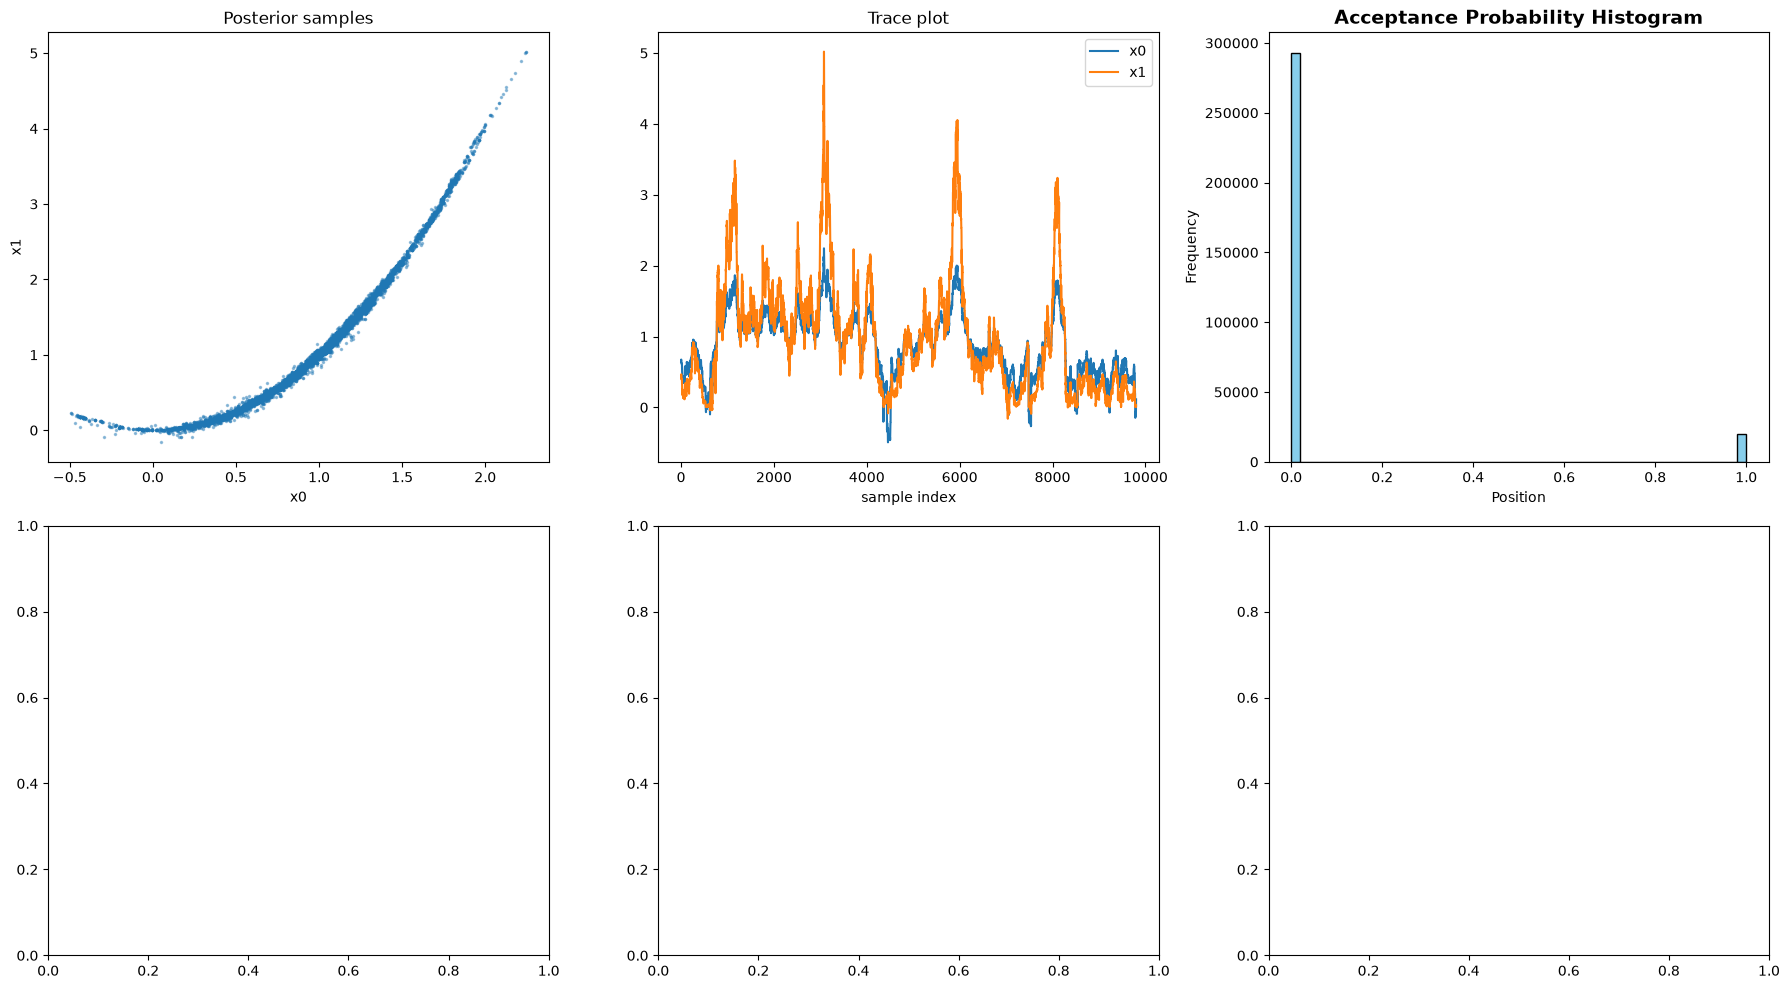

In [12]:
import jax.numpy as jnp
import numpy as np
import jax
import jax.random as jr

from RMHMC import RMHMCSampler
import matplotlib.pyplot as plt

num_overall_steps = 10000
burn_in = 200
prior_cov_matrix = jnp.array([[1.0, 0],
                       [0, 1.0]])
inv_prior_cov_matrix = jnp.linalg.inv(prior_cov_matrix)
measurement_error_bar = 0.1
initial_position = jnp.array([0.0, 0.0])   
rng = jr.PRNGKey(0)

def negative_logdensity(x):
    return 100.0 * (x[1] - x[0]**2)**2 + (1.0 - x[0])**2
    log_P_data_given_signal = 0.5*((jnp.sum(jnp.exp(x)) - 1)/measurement_error_bar)**2
    log_P_signal = 0.5*x.T @ inv_prior_cov_matrix @ x
    return log_P_data_given_signal + log_P_signal

sampler = RMHMCSampler(
    negative_logdensity,
    num_integration_steps=32,
    step_size=0.06,
    alpha=1.0,
    tolerance=1e-8,
    max_iterations=100,
)

positions, momenta, accept_prob_arr = sampler.sample(initial_position, num_overall_steps, burn_in, rng)

print(f"mean acceptance probability: {float(jnp.mean(accept_prob_arr)):.3f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0][0].plot(positions[:, 0], positions[:, 1], '.', alpha=0.4, markersize=3)
axes[0][0].set_xlabel("x0"); axes[0][0].set_ylabel("x1"); axes[0][0].set_title("Posterior samples")

axes[0][1].plot(positions[:, 0], label="x0")
axes[0][1].plot(positions[:, 1], label="x1")
axes[0][1].set_xlabel("sample index"); axes[0][1].set_title("Trace plot"); axes[0][1].legend()

accept_prob_arr = jnp.ravel(accept_prob_arr)
axes[0][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')
axes[0][2].set_title('Acceptance Probability Histogram', fontsize=14, fontweight='bold')
axes[0][2].set_xlabel('Position')
axes[0][2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()